# Human pilot

One participant, one task, ten matched trials per method and depth: FC at
depths 2/4/6/8/10, native FRS and FRS-RA at 1/2/4/6/8, 150 trials
(`experiments/human_pilot.sh`). Set `ROOT` to the participant's output
directory and Run All; every figure and its table are exported under
`<ROOT>/figures/`.

**User authority** is measured from the recording, not read off the depth. At
every step the recording holds the executed translation `a`, the operator's
command `r` and `policy_translation` `p`, the policy's own plan for that step
(for a steered chunk, the chunk it produced from the same observation and the
same noise without the operator). User authority is how far `a` moved from `p`
toward `r`, `⟨a − p, r − p⟩ / ‖r − p‖²` clipped to [0, 1]; policy authority is
its complement. It is taken per action chunk, over the steps where the operator
was pushing — what the channel delivered while it was in use; idle time is the
operator's choice, not the method's — and a trial's value is the mean over its
pushing chunks. Each method/depth cell sits at its mean with a horizontal 95%
interval. Runs recorded before `policy_translation` existed need `replay.py`
first.


## Setup

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

REPO_ROOT = next(
    p
    for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "examples/pi05/libero_shared_autonomy/notebooks/analyze.py").exists()
)
sys.path.insert(0, str(REPO_ROOT / "examples/pi05/libero_shared_autonomy/notebooks"))
import analyze  # noqa: E402

plt.style.use(analyze.PAPER_STYLE)
ROOT = REPO_ROOT / "outputs/human_pilot/p01"
DEPTHS = {"FC": [2, 4, 6, 8, 10], "FRS": [1, 2, 4, 6, 8], "FRS-RA": [1, 2, 4, 6, 8]}
TRIALS_PER_CONDITION = 10

## Load and check

Off-grid blocks (an aborted attempt with another depth grid) are set aside.
The pilot is complete when every cell has `TRIALS_PER_CONDITION` trials on the
same resets; otherwise the figures are labelled partial.


In [2]:
runs = analyze.find_runs(ROOT)
if not runs:
    raise FileNotFoundError(f"No trials in {ROOT}; collect data or change ROOT.")
trials, configs = analyze.load_runs(runs)
if trials.empty:
    raise ValueError("No completed trials yet.")
assert set(trials.operator) == {"human"}, "Select human data only."
assert trials.task_id.nunique() == 1, "Select one task for this pilot figure."
assert not trials.duplicated(["method", "depth", "pair_id"]).any(), "Duplicate trials: check for reruns."
expected = pd.MultiIndex.from_tuples(
    [(m, d) for m, ds in DEPTHS.items() for d in ds], names=["method", "depth"]
)
observed = trials.groupby(["method", "depth"]).size()
off_grid = observed.index.difference(expected)
if not off_grid.empty:
    # e.g. an aborted first attempt with another depth grid; kept out of the figures
    print("Off-grid blocks set aside (not in DEPTHS):")
    print(observed.loc[off_grid].rename("trials").to_string())
    trials = trials[~trials.set_index(["method", "depth"]).index.isin(off_grid)]
    observed = trials.groupby(["method", "depth"]).size()
counts = observed.reindex(expected, fill_value=0).rename("completed")
display(counts.unstack("depth"))
complete = bool((counts == TRIALS_PER_CONDITION).all())
if complete:
    pairs = [set(g.pair_id) for _, g in trials.groupby(["method", "depth"])]
    assert all(p == pairs[0] for p in pairs), "Conditions used different reset assignments."
else:
    print("PARTIAL DATA: the figures will be labeled partial.")
suffix = "" if complete else "_partial"
print(f"{len(trials)} completed trials: {trials.task_description.iloc[0]}")
metrics = analyze.trial_metrics(trials)
if metrics["user_authority"].isna().all():
    raise ValueError(f"No policy_translation in these recordings: run replay.py on {ROOT} first.")
export = ROOT / "figures"
export.mkdir(exist_ok=True)

depth,1.0,2.0,4.0,6.0,8.0,10.0
method,,,,,,
FC,NaN,10.0,10.0,10.0,10.0,10.0
FRS,10.0,10.0,10.0,10.0,10.0,NaN
FRS-RA,10.0,10.0,10.0,10.0,10.0,NaN


150 completed trials: put the bowl on top of the cabinet


## Outcomes versus user authority

Each method's outcomes against the authority it actually gave the operator,
one point per depth, with colour and marker shape identifying the method.
Points are unconnected because depth need not increase with authority.
The panels show success rate, best task progress reached (the bowl's
closest approach to where the successful trials leave it, as a fraction of its
initial distance), end-effector path length, and steps to success among
successes. Faint error bars show Wilson 95% intervals on the rate, t intervals on the means and on
authority. There is no ceiling anchor in the pilot, so progress uses the goal
set from the pilot's own successes.


/home/user/Projects/lerobot/.venv/lib/python3.13/site-packages/scipy/stats/_distn_infrastructure.py:2334: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
/home/user/Projects/lerobot/.venv/lib/python3.13/site-packages/scipy/stats/_distn_infrastructure.py:2335: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


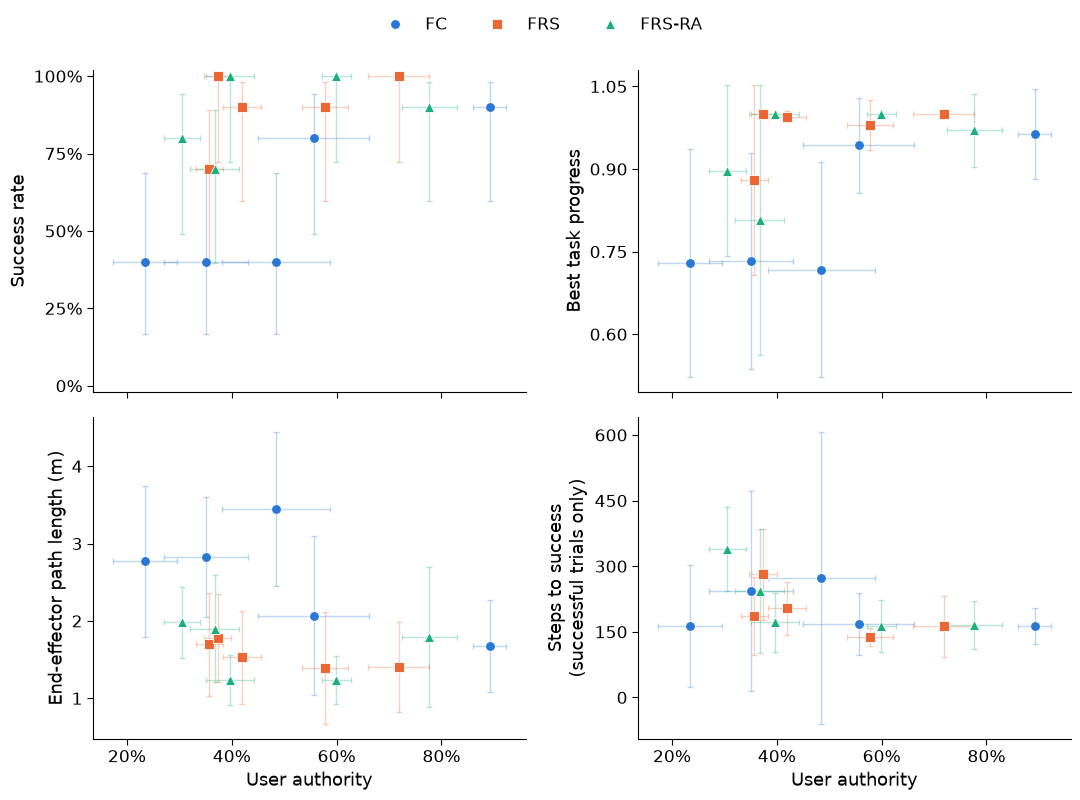

,method,depth,n,value,ci95_low,ci95_high,user_authority,user_authority_ci95_low,user_authority_ci95_high
0,FC,2.0,10,0.4,0.168180,0.687326,0.234380,0.172938,0.295821
1,FC,4.0,10,0.4,0.168180,0.687326,0.350642,0.269937,0.431347
2,FC,6.0,10,0.4,0.168180,0.687326,0.485015,0.382337,0.587693
3,FC,8.0,10,0.8,0.490162,0.943318,0.556097,0.449873,0.662322
4,FC,10.0,10,0.9,0.595850,0.982124,0.892224,0.860755,0.923692
5,FRS,1.0,10,1.0,0.722467,1.000000,0.718130,0.660580,0.775680
6,FRS,2.0,10,0.9,0.595850,0.982124,0.577607,0.533173,0.622041
7,FRS,4.0,10,0.9,0.595850,0.982124,0.418802,0.382746,0.454858
8,FRS,6.0,10,0.7,0.396778,0.892209,0.357276,0.331610,0.382942
9,FRS,8.0,10,1.0,0.722467,1.000000,0.373283,0.347071,0.399496


In [3]:
panels = ["success", "progress_max", "path_length", "time_to_success"]
fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True)
tables = [
    analyze.plot_metric(metrics, ax, m, legend=False) for m, ax in zip(panels, axes.ravel(), strict=True)
]
for ax in axes[0]:
    ax.set_xlabel("")
axes[1, 1].set_ylabel("Steps to success\n(successful trials only)")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(labels), bbox_to_anchor=(0.5, 1.01))
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(export / f"outcomes_vs_authority{suffix}.png", dpi=220, bbox_inches="tight")
fig.savefig(export / f"outcomes_vs_authority{suffix}.svg", bbox_inches="tight")
pd.concat(tables, keys=panels, names=["metric"]).to_csv(export / f"outcomes_vs_authority{suffix}.csv")
plt.show()
display(tables[0])

## Head to head at each method's best depth

Each method at the depth where it scored best **on this pilot**
(`analyze.best_vs_best`; ties go to the lowest depth), compared on the matched
resets: success, the authority it gave, task progress, path length and steps
to success. Brackets mark the paired test between two methods — McNemar's
exact test for success, the Wilcoxon signed-rank test for the rest —
`*` p < 0.05, `**` p < 0.01, `***` p < 0.001, `n.s.` otherwise; the statistics
behind the marks are in the exported tables. Selecting and testing on the same
ten trials is optimistic for every method alike, and with ten pairs a McNemar
test needs at least six discordant pairs to reach 0.05.


/home/user/Projects/lerobot/.venv/lib/python3.13/site-packages/scipy/stats/_distn_infrastructure.py:2334: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
/home/user/Projects/lerobot/.venv/lib/python3.13/site-packages/scipy/stats/_distn_infrastructure.py:2335: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


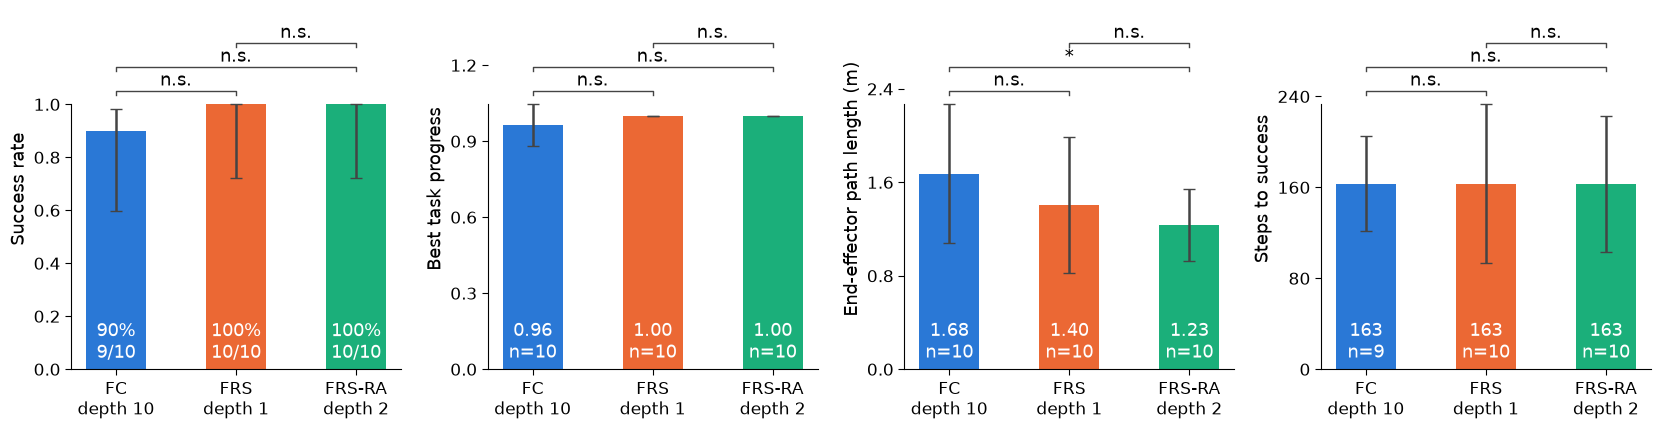

A       B  paired_trials  A_rate  B_rate  A_only  B_only  \
metric                                                                          
success         0   FC     FRS             10     0.9     1.0     0.0     1.0   
                1   FC  FRS-RA             10     0.9     1.0     0.0     1.0   
                2  FRS  FRS-RA             10     1.0     1.0     0.0     0.0   
progress_max    0   FC     FRS             10     NaN     NaN     NaN     NaN   
                1   FC  FRS-RA             10     NaN     NaN     NaN     NaN   
                2  FRS  FRS-RA             10     NaN     NaN     NaN     NaN   
path_length     0   FC     FRS             10     NaN     NaN     NaN     NaN   
                1   FC  FRS-RA             10     NaN     NaN     NaN     NaN   
                2  FRS  FRS-RA             10     NaN     NaN     NaN     NaN   
time_to_success 0   FC     FRS              9     NaN     NaN     NaN     NaN   
                1   FC  FRS-RA              9     NaN     NaN     NaN     NaN   
                2  FRS  FRS-RA             10     NaN     NaN     NaN     NaN   

                   discordant  mcnemar_p         p      A_mean      B_mean  \
metric                                                                       
success         0         1.0        1.0  1.000000         NaN         NaN   
                1         1.0        1.0  1.000000         NaN         NaN   
                2         0.0        NaN       NaN         NaN         NaN   
progress_max    0         NaN        NaN  1.000000    0.963935    1.000000   
                1         NaN        NaN  1.000000    0.963935    1.000000   
                2         NaN        NaN       NaN    1.000000    1.000000   
path_length     0         NaN        NaN  0.322266    1.675429    1.403733   
                1         NaN        NaN  0.048828    1.675429    1.233034   
                2         NaN        NaN  0.921875    1.403733    1.233034   
time_to_success 0         NaN        NaN  0.843750  163.111111  169.888889   
                1         NaN        NaN  0.910156  163.111111  168.000000   
                2         NaN        NaN  0.640625  163.100000  163.300000   

                   mean_difference  wilcoxon_p  
metric                                          
success         0              NaN         NaN  
                1              NaN         NaN  
                2              NaN         NaN  
progress_max    0         0.036065    1.000000  
                1         0.036065    1.000000  
                2         0.000000         NaN  
path_length     0        -0.271696    0.322266  
                1        -0.442396    0.048828  
                2        -0.170700    0.921875  
time_to_success 0         6.777778    0.843750  
                1         4.888889    0.910156  
                2         0.200000    0.640625

In [4]:
best, comparisons, at_best = analyze.best_vs_best(trials)
head_to_head = ["success", "progress_max", "path_length", "time_to_success"]
fig, axes = plt.subplots(1, len(head_to_head), figsize=(4.2 * len(head_to_head), 4.5))
tables = {
    m: analyze.plot_best_vs_best(metrics.loc[at_best.index], ax, m)
    for m, ax in zip(head_to_head, axes, strict=True)
}
fig.tight_layout()
fig.savefig(export / f"best_vs_best{suffix}.png", dpi=220, bbox_inches="tight")
fig.savefig(export / f"best_vs_best{suffix}.svg", bbox_inches="tight")
pd.concat({m: t for m, (t, _) in tables.items()}, names=["metric"]).to_csv(
    export / f"best_vs_best{suffix}.csv"
)
pd.concat({m: c for m, (_, c) in tables.items()}, names=["metric"]).to_csv(
    export / f"best_vs_best_comparisons{suffix}.csv"
)
plt.show()
display(pd.concat({m: c for m, (_, c) in tables.items()}, names=["metric"]))

## Success over time

The fraction of trials done by step *k* at each method's best depth: the
censoring-safe view of trial time (failures ran to the 600-step cap).


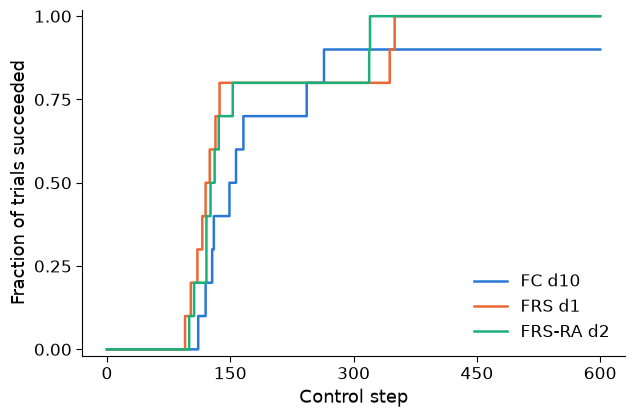

Figures and tables saved under /home/user/Projects/lerobot/outputs/human_pilot/p01/figures


In [5]:
over_time = metrics.loc[at_best.index].copy()
over_time["method"] = over_time["method"] + " d" + over_time["depth"].astype(int).astype(str)
fig, ax = plt.subplots(figsize=(7, 4.5))
analyze.plot_success_over_time(over_time, ax)
fig.savefig(export / f"success_over_time{suffix}.png", dpi=220, bbox_inches="tight")
plt.show()
print(f"Figures and tables saved under {export}")

## Notes

Error bars are descriptive 95% intervals (Wilson for rates, t for means).
Report participant count, ten attempts per point, all depths, corruption +20°,
adaptor translation angle +40°, ten-action chunks and the common 600-step cap.
Human commands receive no synthetic delay. This is an exploratory human pilot,
not a confirmed population-level advantage. The launcher accepts `ORDER`,
`FC_DEPTHS` and `FRS_DEPTHS` to vary method/depth order across participants;
account for practice and fatigue.
